# Predicting the Sale Price of Bulldozers using Machine Learning

In this notebook, we're going to go through an example machine learning project to use the characteristics of bulldozers and their past sales prices to predict the sale price of future bulldozers based on their characteristics.

- **Inputs**: Bulldozer characteristics such as make year, base model, model series, state of sale (e.g. which US state was it sold in), drive system and more.
- **Outputs**: Bulldozer sale price (in USD).
Since we're trying to predict a number, this kind of problem is known as a **regression problem**.

And since we're going to predicting results with a time component (predicting future sales based on past sales), this is also known as a **time series** or **forecasting problem**.

## 1. Problem Definition
For this dataset, the problem we're trying to solve, or better, the question we're trying to answer is,

How well can we predict the future sale price of a bulldozer, given its characteristics previous examples of how much similar bulldozers have been sold for?

## 2. Data
Looking at the dataset from Kaggle, you can you it's a time series problem. This means there's a time attribute to dataset.

In this case, it's historical sales data of bulldozers. Including things like, model type, size, sale date and more.

There are 3 datasets:

- **Train.csv** - Historical bulldozer sales examples up to 2011 (close to 400,000 examples with 50+ different attributes, including `SalePrice` which is the **target variable**).

- **Valid.csv** - Historical bulldozer sales examples from January 1 2012 to April 30 2012 (close to 12,000 examples with the same attributes as **Train.csv**).

- **Test.csv** - Historical bulldozer sales examples from May 1 2012 to November 2012 (close to 12,000 examples but missing the SalePrice attribute, as this is what we'll be trying to predict).

Note: You can download the dataset `bluebook-for-bulldozers` dataset directly from Kaggle. Alternatively, you can also download it directly from the course GitHub.

## 3. Evaluation
For this problem, Kaggle has set the evaluation metric to being root mean squared log error (RMSLE). As with many regression evaluations, the goal will be to get this value as low as possible.

To see how well our model is doing, we'll calculate the RMSLE and then compare our results to others on the Kaggle leaderboard.

## 4. Features
Features are different parts of the data. During this step, you'll want to start finding out what you can about the data.

One of the most common ways to do this is to create a **data dictionary**.

For this dataset, Kaggle provides a data dictionary which contains information about what each attribute of the dataset means.

For example:

**Variable Name**	  **Description**	  **Variable Type**

SalesID	unique identifier of a particular sale of a machine at auction	Independent variable

MachineID	identifier for a particular machine; machines may have multiple sales	Independent variable

ModelID	identifier for a unique machine model (i.e. fiModelDesc)	Independent variable

datasource	source of the sale record; some sources are more diligent about reporting attributes of the machine than others. Note that a particular datasource may report on multiple auctioneerIDs.	Independent variable

auctioneerID	identifier of a particular auctioneer, i.e. company that sold the machine at auction. Not the same as datasource.	Independent variable

YearMade	year of manufacturer of the Machine	Independent variable

MachineHoursCurrentMeter	current usage of the machine in hours at time of sale (saledate); null or 0 means no hours have been reported for that sale	Independent variable

UsageBand	value (low, medium, high) calculated comparing this particular Machine-Sale hours to average usage for the fiBaseModel; e.g. 'Low' means this machine has fewer hours given its lifespan relative to the average of fiBaseModel.	Independent variable

Saledate	time of sale	Independent variable

fiModelDesc	Description of a unique machine model (see ModelID); concatenation of fiBaseModel & fiSecondaryDesc & fiModelSeries & fiModelDescriptor	Independent variable

State	US State in which sale occurred	Independent variable

Drive_System	machine configuration; typically describes whether 2 or 4 wheel drive	Independent variable

Enclosure	machine configuration - does the machine have an enclosed cab or not	Independent variable

Forks	machine configuration - attachment used for lifting	Independent variable

Pad_Type	machine configuration - type of treads a crawler machine uses	Independent variable

Ride_Control	machine configuration - optional feature on loaders to make the ride smoother	Independent variable

Transmission	machine configuration - describes type of transmission; typically automatic or manual	Independent variable

...	...	...

SalePrice	cost of sale in USD	Target/dependent variable

You can download the full version of this file directly from the Kaggle competition page (account required) or view it on Google Sheets.

With all of this being known, let's get started!

First, we'll import the dataset and start exploring. Since we know the evaluation metric we're trying to minimise, our first goal will be building a baseline model and seeing how it stacks up against the competition

In [ ]:
# Timestamp
import datetime

import datetime
print(f"Notebook last run (end-to-end): {datetime.datetime.now()}")

Notebook last run (end-to-end): 2026-10-01 05:29:08.138442


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

In [ ]:
# import training and validation sets
df = pd.read_csv("/content/TrainAndValid.csv",
                 low_memory=False)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257443 entries, 0 to 257442
Data columns (total 53 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   SalesID                   257443 non-null  int64  
 1   SalePrice                 257443 non-null  int64  
 2   MachineID                 257443 non-null  int64  
 3   ModelID                   257443 non-null  int64  
 4   datasource                257443 non-null  int64  
 5   auctioneerID              257443 non-null  int64  
 6   YearMade                  257443 non-null  int64  
 7   MachineHoursCurrentMeter  33789 non-null   float64
 8   UsageBand                 30863 non-null   object 
 9   saledate                  257443 non-null  object 
 10  fiModelDesc               257443 non-null  object 
 11  fiBaseModel               257443 non-null  object 
 12  fiSecondaryDesc           172507 non-null  object 
 13  fiModelSeries             37219 non-null   o

In [ ]:
df.isna().sum()

,0
SalesID,0
SalePrice,0
MachineID,0
ModelID,0
datasource,0
auctioneerID,0
YearMade,0
MachineHoursCurrentMeter,223654
UsageBand,226580
saledate,0


In [ ]:
df.columns

Index(['SalesID', 'SalePrice', 'MachineID', 'ModelID', 'datasource',
       'auctioneerID', 'YearMade', 'MachineHoursCurrentMeter', 'UsageBand',
       'saledate', 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc',
       'fiModelSeries', 'fiModelDescriptor', 'ProductSize',
       'fiProductClassDesc', 'state', 'ProductGroup', 'ProductGroupDesc',
       'Drive_System', 'Enclosure', 'Forks', 'Pad_Type', 'Ride_Control',
       'Stick', 'Transmission', 'Turbocharged', 'Blade_Extension',
       'Blade_Width', 'Enclosure_Type', 'Engine_Horsepower', 'Hydraulics',
       'Pushblock', 'Ripper', 'Scarifier', 'Tip_Control', 'Tire_Size',
       'Coupler', 'Coupler_System', 'Grouser_Tracks', 'Hydraulics_Flow',
       'Track_Type', 'Undercarriage_Pad_Width', 'Stick_Length', 'Thumb',
       'Pattern_Changer', 'Grouser_Type', 'Backhoe_Mounting', 'Blade_Type',
       'Travel_Controls', 'Differential_Type', 'Steering_Controls'],
      dtype='object')

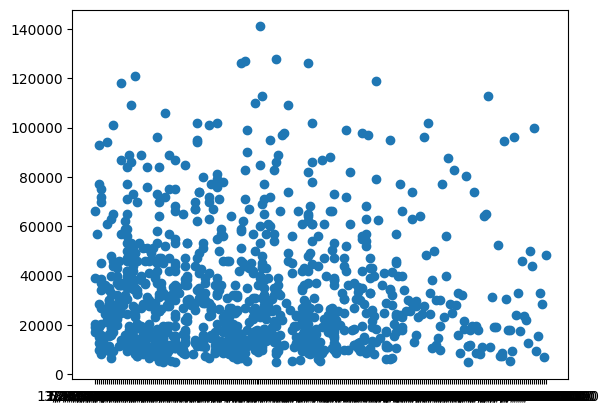

In [ ]:
fig,ax = plt.subplots()
ax.scatter(df["saledate"][:1000], df["SalePrice"][:1000])

In [ ]:
df["saledate"][:1000]

,saledate
0,11/16/2006 0:00
1,3/26/2004 0:00
2,2/26/2004 0:00
3,5/19/2011 0:00
4,7/23/2009 0:00
...,...
995,7/16/2009 0:00
996,6/14/2007 0:00
997,9/22/2005 0:00
998,7/28/2005 0:00


<Axes: ylabel='Frequency'>

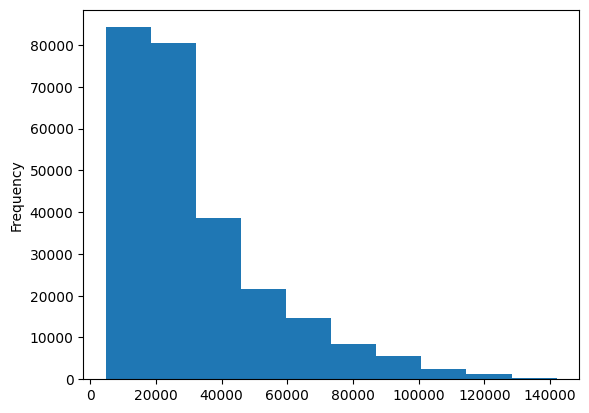

In [ ]:
df["SalePrice"].plot.hist()

###  Parsing dates
When working with time series data, it's a good idea to make sure any date data is the format of a datetime object (a Python data type which encodes specific information about dates).

We can tell pandas which columns to read in as dates by setting the `parse_dates` parameter in `pd.read_csv`.

Once we've imported our CSV with the saledate column parsed, we can view information about our DataFrame again with `df.info()`.

In [ ]:
# import data again but this time parse dates
df = pd.read_csv("/content/TrainAndValid.csv",
                 low_memory=False,
                 parse_dates=["saledate"])

In [ ]:
df.saledate.dtype

dtype('<M8[ns]')

In [ ]:
df.saledate[:1000]

,saledate
0,2006-11-16
1,2004-03-26
2,2004-02-26
3,2011-05-19
4,2009-07-23
...,...
995,2009-07-16
996,2007-06-14
997,2005-09-22
998,2005-07-28


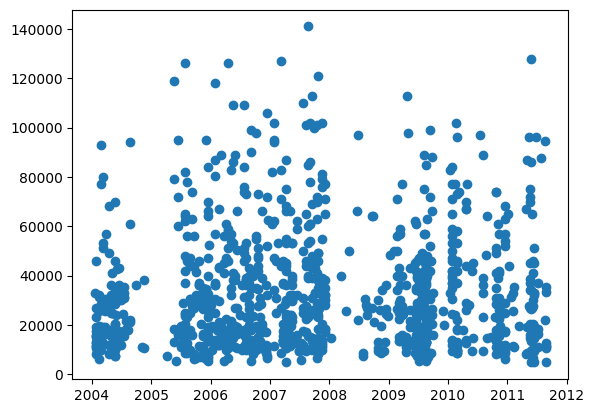

In [ ]:
fig, ax = plt.subplots()
ax.scatter(df["saledate"][:1000], df["SalePrice"][:1000])

In [ ]:
df.head()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1139246,66000,999089,3157,121,3.0,2004,68.0,Low,2006-11-16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139248,57000,117657,77,121,3.0,1996,4640.0,Low,2004-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1139249,10000,434808,7009,121,3.0,2001,2838.0,High,2004-02-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1139251,38500,1026470,332,121,3.0,2001,3486.0,High,2011-05-19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139253,11000,1057373,17311,121,3.0,2007,722.0,Medium,2009-07-23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.head().T

,0,1,2,3,4
SalesID,1139246,1139248,1139249,1139251,1139253
SalePrice,66000,57000,10000,38500,11000
MachineID,999089,117657,434808,1026470,1057373
ModelID,3157,77,7009,332,17311
datasource,121,121,121,121,121
auctioneerID,3.0,3.0,3.0,3.0,3.0
YearMade,2004,1996,2001,2001,2007
MachineHoursCurrentMeter,68.0,4640.0,2838.0,3486.0,722.0
UsageBand,Low,Low,High,High,Medium
saledate,2006-11-16 00:00:00,2004-03-26 00:00:00,2004-02-26 00:00:00,2011-05-19 00:00:00,2009-07-23 00:00:00


In [ ]:
df.saledate.head(20)

,saledate
0,2006-11-16
1,2004-03-26
2,2004-02-26
3,2011-05-19
4,2009-07-23
5,2008-12-18
6,2004-08-26
7,2005-11-17
8,2009-08-27
9,2007-08-09


### Sorting our DataFrame by saledate
Now we've formatted our `saledate` column to be NumPy datetime64[ns] objects, we can use built-in pandas methods such as `sort_values` to sort our DataFrame by date.

And considering this is a time series problem, sorting our DataFrame by date has the added benefit of making sure our data is sequential.

In other words, we want to use examples from the past (example sale prices from previous dates) to try and predict future bulldozer sale prices.

Let's use the `pandas.DataFrame.sort_values` method to sort our DataFrame by `saledate` in ascending order.

In [ ]:
# sort DataFrame in date order
df.sort_values(by=["saledate"], inplace=True,
               ascending=True)

In [ ]:
df.saledate.head(10)

,saledate
205615,1989-01-17
134119,1989-01-31
63167,1989-01-31
32317,1989-01-31
98567,1989-01-31
140257,1989-01-31
119199,1989-01-31
54438,1989-01-31
233186,1989-01-31
66337,1989-01-31


### Make a copy of the original dataframe so when we manipulate the copy, we've still got our original data.

In [ ]:
# Make a copy
df_tmp = df.copy()
df_tmp

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
205615,1646770,9500,1126363,8434,132,18.0,1974,NaN,NaN,1989-01-17,...,NaN,NaN,NaN,NaN,NaN,None or Unspecified,Straight,None or Unspecified,NaN,NaN
134119,1491351,50000,846943,4107,132,99.0,1987,NaN,NaN,1989-01-31,...,NaN,NaN,NaN,NaN,NaN,None or Unspecified,PAT,None or Unspecified,NaN,NaN
63167,1329620,26500,1253848,4089,132,99.0,1987,NaN,NaN,1989-01-31,...,NaN,NaN,NaN,NaN,NaN,None or Unspecified,PAT,None or Unspecified,NaN,NaN
32317,1265202,21000,1385055,6788,132,99.0,1984,NaN,NaN,1989-01-31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98567,1415950,40000,1142272,3357,132,99.0,1978,NaN,NaN,1989-01-31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23972,1222821,100000,1016175,16725,121,3.0,2005,9341.0,High,2011-12-29,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
23968,1222813,102000,1038562,13316,121,3.0,2006,1764.0,Low,2011-12-29,...,32 inch,None or Unspecified,None or Unspecified,Yes,Double,NaN,NaN,NaN,NaN,NaN
23970,1222817,11000,999753,25175,121,3.0,2002,7140.0,High,2011-12-29,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23971,1222820,100000,1010621,16725,121,3.0,2005,9946.0,High,2011-12-29,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional


### Adding extra features to our DataFrame

One way to potentially increase the predictive power of our data is to enhance it with more features.

This practice is known as feature engineering, taking existing features and using them to create more/different features.

There is no set in stone way to do feature engineering and often it takes quite a bit of practice/exploration/experimentation to figure out what might work and what won't.

For now, we'll use our `saledate` column to add extra features such as:

- Year of sale
- Month of sale
- Day of sale
- Day of week sale (e.g. Monday = 1, Tuesday = 2)
- Day of year sale (e.g. January 1st = 1, January 2nd = 2)

In [ ]:
df_tmp["saleYear"] = df_tmp.saledate.dt.year
df_tmp["saleMonth"] = df_tmp.saledate.dt.month
df_tmp["saleDay"] = df_tmp.saledate.dt.day
df_tmp["saleDayofweek"] = df_tmp.saledate.dt.dayofweek
df_tmp["saleDayofyear"] = df_tmp.saledate.dt.dayofyear

In [ ]:
df_tmp.columns

Index(['SalesID', 'SalePrice', 'MachineID', 'ModelID', 'datasource',
       'auctioneerID', 'YearMade', 'MachineHoursCurrentMeter', 'UsageBand',
       'saledate', 'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc',
       'fiModelSeries', 'fiModelDescriptor', 'ProductSize',
       'fiProductClassDesc', 'state', 'ProductGroup', 'ProductGroupDesc',
       'Drive_System', 'Enclosure', 'Forks', 'Pad_Type', 'Ride_Control',
       'Stick', 'Transmission', 'Turbocharged', 'Blade_Extension',
       'Blade_Width', 'Enclosure_Type', 'Engine_Horsepower', 'Hydraulics',
       'Pushblock', 'Ripper', 'Scarifier', 'Tip_Control', 'Tire_Size',
       'Coupler', 'Coupler_System', 'Grouser_Tracks', 'Hydraulics_Flow',
       'Track_Type', 'Undercarriage_Pad_Width', 'Stick_Length', 'Thumb',
       'Pattern_Changer', 'Grouser_Type', 'Backhoe_Mounting', 'Blade_Type',
       'Travel_Controls', 'Differential_Type', 'Steering_Controls', 'saleYear',
       'saleMonth', 'saleDay', 'saleDayofweek', 'saleDayofyear'],

In [ ]:
df_tmp.head()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,...,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls,saleYear,saleMonth,saleDay,saleDayofweek,saleDayofyear
205615,1646770,9500,1126363,8434,132,18.0,1974,NaN,NaN,1989-01-17,...,None or Unspecified,Straight,None or Unspecified,NaN,NaN,1989,1,17,1,17
134119,1491351,50000,846943,4107,132,99.0,1987,NaN,NaN,1989-01-31,...,None or Unspecified,PAT,None or Unspecified,NaN,NaN,1989,1,31,1,31
63167,1329620,26500,1253848,4089,132,99.0,1987,NaN,NaN,1989-01-31,...,None or Unspecified,PAT,None or Unspecified,NaN,NaN,1989,1,31,1,31
32317,1265202,21000,1385055,6788,132,99.0,1984,NaN,NaN,1989-01-31,...,NaN,NaN,NaN,NaN,NaN,1989,1,31,1,31
98567,1415950,40000,1142272,3357,132,99.0,1978,NaN,NaN,1989-01-31,...,NaN,NaN,NaN,NaN,NaN,1989,1,31,1,31


In [ ]:
df_tmp.head().T

,205615,134119,63167,32317,98567
SalesID,1646770,1491351,1329620,1265202,1415950
SalePrice,9500,50000,26500,21000,40000
MachineID,1126363,846943,1253848,1385055,1142272
ModelID,8434,4107,4089,6788,3357
datasource,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0
YearMade,1974,1987,1987,1984,1978
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN
saledate,1989-01-17 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00,1989-01-31 00:00:00


In [ ]:
# No we've enriched our Dataframe with date time features, we can remove 'saledate'
df_tmp.drop("saledate", axis=1, inplace=True)

In [ ]:
# check the values of different columns
df_tmp.state.value_counts()

,count
state,
Florida,57123
Texas,42731
California,24469
Washington,13116
Georgia,11979
Mississippi,11713
Ohio,10925
Maryland,10474
New Jersey,10126


## 5. Modelling

We've done enoug EDA (we could always do more) but let's start todo some model-driven EDA

In [ ]:
# Let's build a machine learning model
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_jobs=1,
                              random_state=42)

### Convert strings to categories

One way we can turn all of our data into numbers is by converting them into pandas categories

In [ ]:
df_tmp.head().T

,205615,134119,63167,32317,98567
SalesID,1646770,1491351,1329620,1265202,1415950
SalePrice,9500,50000,26500,21000,40000
MachineID,1126363,846943,1253848,1385055,1142272
ModelID,8434,4107,4089,6788,3357
datasource,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0
YearMade,1974,1987,1987,1984,1978
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN
fiModelDesc,TD20,D4H,D3B,580,12G


In [ ]:
pd.api.types.is_string_dtype(df_tmp["UsageBand"])

False

In [ ]:
# Find the columns which contian strings
for label, content in df_tmp.items():
  if pd.api.types.is_string_dtype(content):
     print(label)

fiModelDesc
fiBaseModel
fiProductClassDesc
state
ProductGroup
ProductGroupDesc


In [ ]:
# This will turn all of the string value into category values
for label, content in df_tmp.items():
  if pd.api.types.is_string_dtype(content):
    df_tmp[label] = content.astype("category").cat.as_ordered()

In [ ]:
df_tmp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 347518 entries, 205615 to 23967
Data columns (total 57 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   SalesID                   347518 non-null  int64   
 1   SalePrice                 347518 non-null  int64   
 2   MachineID                 347518 non-null  int64   
 3   ModelID                   347518 non-null  int64   
 4   datasource                347518 non-null  int64   
 5   auctioneerID              330302 non-null  float64 
 6   YearMade                  347518 non-null  int64   
 7   MachineHoursCurrentMeter  97943 non-null   float64 
 8   UsageBand                 44206 non-null   object  
 9   fiModelDesc               347518 non-null  category
 10  fiBaseModel               347518 non-null  category
 11  fiSecondaryDesc           230049 non-null  object  
 12  fiModelSeries             45211 non-null   object  
 13  fiModelDescriptor         5925

In [ ]:
df_tmp.state.cat.categories

Index(['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado',
       'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho',
       'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana',
       'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
       'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada',
       'New Hampshire', 'New Jersey', 'New Mexico', 'New York',
       'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon',
       'Pennsylvania', 'Puerto Rico', 'Rhode Island', 'South Carolina',
       'South Dakota', 'Tennessee', 'Texas', 'Unspecified', 'Utah', 'Vermont',
       'Virginia', 'Washington', 'Washington DC', 'West Virginia', 'Wisconsin',
       'Wyoming'],
      dtype='object')

In [ ]:
df_tmp.state.value_counts()

,count
state,
Florida,57123
Texas,42731
California,24469
Washington,13116
Georgia,11979
Mississippi,11713
Ohio,10925
Maryland,10474
New Jersey,10126


In [ ]:
df_tmp.state.cat.codes

,0
205615,43
134119,8
63167,8
32317,8
98567,8
...,...
23972,43
23968,4
23970,4
23971,43


Thanks to pandas categories we now have a way to access all of our data in the form of numbers.

But we still have a bunch of missing data...

In [ ]:
# check missing data
df_tmp.isnull().sum() / len(df_tmp)

,0
SalesID,0.000000
SalePrice,0.000000
MachineID,0.000000
ModelID,0.000000
datasource,0.000000
auctioneerID,0.049540
YearMade,0.000000
MachineHoursCurrentMeter,0.718164
UsageBand,0.872795
fiModelDesc,0.000000


### Save preprocessed data

In [ ]:
# Export current tmp dataframe
df_tmp.to_csv("/content/train_tmp.csv",
              index=False)

In [ ]:
# import preprocessed data
df_tmp = pd.read_csv("/content/train_tmp.csv",
                     low_memory=False)
df_tmp.head().T

,0,1,2,3,4
SalesID,1646770,1491351,1329620,1265202,1415950
SalePrice,9500,50000,26500,21000,40000
MachineID,1126363,846943,1253848,1385055,1142272
ModelID,8434,4107,4089,6788,3357
datasource,132,132,132,132,132
auctioneerID,18.0,99.0,99.0,99.0,99.0
YearMade,1974,1987,1987,1984,1978
MachineHoursCurrentMeter,NaN,NaN,NaN,NaN,NaN
UsageBand,NaN,NaN,NaN,NaN,NaN
fiModelDesc,TD20,D4H,D3B,580,12G


In [ ]:
df_tmp.isna().sum()

,0
SalesID,0
SalePrice,0
MachineID,0
ModelID,0
datasource,0
auctioneerID,17216
YearMade,0
MachineHoursCurrentMeter,249575
UsageBand,303312
fiModelDesc,0


### Fill missing values

### Fill numerical missing values first

In [ ]:
for label, content in df_tmp.items():
  if pd.api.types.is_numeric_dtype(content):
    print(label)

SalesID
SalePrice
MachineID
ModelID
datasource
auctioneerID
YearMade
MachineHoursCurrentMeter
saleYear
saleMonth
saleDay
saleDayofweek
saleDayofyear


In [ ]:
df_tmp.ModelID

,ModelID
0,8434
1,4107
2,4089
3,6788
4,3357
...,...
347513,16725
347514,13316
347515,25175
347516,16725


In [ ]:
# check for which numeric columns have null values
for label, content in df_tmp.items():
  if pd.api.types.is_numeric_dtype(content):
    if pd.isnull(content).sum():
      print(label)

auctioneerID
MachineHoursCurrentMeter


In [ ]:
# Fill numeric rows with the median
for label, content in df_tmp.items():
  if pd.api.types.is_numeric_dtype(content):
    if pd.isnull(content).sum():
      # add a binary column which tells us if the data was missing
      df_tmp[label+"_is_missing"] = pd.isnull(content)
      # fill missing numeric values with median
      df_tmp[label] = content.fillna(content.median())

In [ ]:
# check if there's any null numeric values
for label, content in df_tmp.items():
  if pd.api.types.is_numeric_dtype(content):
    if pd.isnull(content).sum():
      print(label)

In [ ]:
# check to see how many examples were missing
df_tmp.auctioneerID_is_missing.value_counts()

,count
auctioneerID_is_missing,
False,330302
True,17216


In [ ]:
df_tmp.isna().sum()

,0
SalesID,0
SalePrice,0
MachineID,0
ModelID,0
datasource,0
auctioneerID,0
YearMade,0
MachineHoursCurrentMeter,0
UsageBand,303312
fiModelDesc,0


### Filling and turning categorical varibles into numbers

In [ ]:
# check for columns which aren't numeric
for label, content in df_tmp.items():
  if not pd.api.types.is_numeric_dtype(content):
    print(label)

UsageBand
fiModelDesc
fiBaseModel
fiSecondaryDesc
fiModelSeries
fiModelDescriptor
ProductSize
fiProductClassDesc
state
ProductGroup
ProductGroupDesc
Drive_System
Enclosure
Forks
Pad_Type
Ride_Control
Stick
Transmission
Turbocharged
Blade_Extension
Blade_Width
Enclosure_Type
Engine_Horsepower
Hydraulics
Pushblock
Ripper
Scarifier
Tip_Control
Tire_Size
Coupler
Coupler_System
Grouser_Tracks
Hydraulics_Flow
Track_Type
Undercarriage_Pad_Width
Stick_Length
Thumb
Pattern_Changer
Grouser_Type
Backhoe_Mounting
Blade_Type
Travel_Controls
Differential_Type
Steering_Controls


In [ ]:
pd.Categorical(df_tmp["state"])

['Texas', 'Florida', 'Florida', 'Florida', 'Florida', ..., 'Texas', 'California', 'California', 'Texas', 'Hawaii']
Length: 347518
Categories (53, object): ['Alabama', 'Alaska', 'Arizona', 'Arkansas', ..., 'Washington DC',
                          'West Virginia', 'Wisconsin', 'Wyoming']

In [ ]:
pd.Categorical(df_tmp["state"]).codes

array([43,  8,  8, ...,  4, 43, 10], dtype=int8)

In [ ]:
# turn categorical variables into numbers and fill missing
for label, content in df_tmp.items():
  if not pd.api.types.is_numeric_dtype(content):
    # Add binary column to indicate whether sample had missing values
    df_tmp[label+"_is_missing"""] = pd.isnull(content)
    # Turn categories into numbers and add + 1
    df_tmp[label] = pd.Categorical(content).codes+1

In [ ]:
pd.Categorical(df_tmp["state"]).codes+1

array([44,  9,  9, ...,  5, 44, 11], dtype=int8)

In [ ]:
pd.Categorical(df_tmp["UsageBand"]).codes+1

array([1, 1, 1, ..., 2, 2, 3], dtype=int8)

In [ ]:
df_tmp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 347518 entries, 0 to 347517
Columns: 103 entries, SalesID to Steering_Controls_is_missing
dtypes: bool(46), float64(2), int16(3), int64(11), int8(41)
memory usage: 65.3 MB


In [ ]:
df_tmp.head().T

,0,1,2,3,4
SalesID,1646770,1491351,1329620,1265202,1415950
SalePrice,9500,50000,26500,21000,40000
MachineID,1126363,846943,1253848,1385055,1142272
ModelID,8434,4107,4089,6788,3357
datasource,132,132,132,132,132
...,...,...,...,...,...
Backhoe_Mounting_is_missing,False,False,False,True,True
Blade_Type_is_missing,False,False,False,True,True
Travel_Controls_is_missing,False,False,False,True,True
Differential_Type_is_missing,True,True,True,True,True


In [ ]:
df_tmp.isna().sum()[:20]

,0
SalesID,0
SalePrice,0
MachineID,0
ModelID,0
datasource,0
auctioneerID,0
YearMade,0
MachineHoursCurrentMeter,0
UsageBand,0
fiModelDesc,0


Now that alll of data is numeric as well as our dataframe has no missing values, we should be able to build a machine learning model

In [ ]:
df_tmp.head()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,...,Undercarriage_Pad_Width_is_missing,Stick_Length_is_missing,Thumb_is_missing,Pattern_Changer_is_missing,Grouser_Type_is_missing,Backhoe_Mounting_is_missing,Blade_Type_is_missing,Travel_Controls_is_missing,Differential_Type_is_missing,Steering_Controls_is_missing
0,1646770,9500,1126363,8434,132,18.0,1974,0.0,0,4128,...,True,True,True,True,True,False,False,False,True,True
1,1491351,50000,846943,4107,132,99.0,1987,0.0,0,2020,...,True,True,True,True,True,False,False,False,True,True
2,1329620,26500,1253848,4089,132,99.0,1987,0.0,0,1963,...,True,True,True,True,True,False,False,False,True,True
3,1265202,21000,1385055,6788,132,99.0,1984,0.0,0,992,...,True,True,True,True,True,True,True,True,True,True
4,1415950,40000,1142272,3357,132,99.0,1978,0.0,0,78,...,True,True,True,True,True,True,True,True,True,True


In [ ]:
len(df_tmp)

347518

In [ ]:
%%time
# Instantiate model
model = RandomForestRegressor(n_jobs=1,
                              random_state=42)

# fit the model
model.fit(df_tmp.drop("SalePrice", axis=1), df_tmp["SalePrice"])

CPU times: user 10min 36s, sys: 1.64 s, total: 10min 38s
Wall time: 11min 35s


RandomForestRegressor(n_jobs=1, random_state=42)

In [ ]:
# score the model
model.score(df_tmp.drop("SalePrice", axis=1), df_tmp["SalePrice"])

0.9873223714554505

**Questions** Why doesn't the above metric hold water? (why isn't he metric reliable)

### Splitting data into train/validation sets

In [ ]:
df_tmp.head()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,...,Undercarriage_Pad_Width_is_missing,Stick_Length_is_missing,Thumb_is_missing,Pattern_Changer_is_missing,Grouser_Type_is_missing,Backhoe_Mounting_is_missing,Blade_Type_is_missing,Travel_Controls_is_missing,Differential_Type_is_missing,Steering_Controls_is_missing
0,1646770,9500,1126363,8434,132,18.0,1974,0.0,0,4128,...,True,True,True,True,True,False,False,False,True,True
1,1491351,50000,846943,4107,132,99.0,1987,0.0,0,2020,...,True,True,True,True,True,False,False,False,True,True
2,1329620,26500,1253848,4089,132,99.0,1987,0.0,0,1963,...,True,True,True,True,True,False,False,False,True,True
3,1265202,21000,1385055,6788,132,99.0,1984,0.0,0,992,...,True,True,True,True,True,True,True,True,True,True
4,1415950,40000,1142272,3357,132,99.0,1978,0.0,0,78,...,True,True,True,True,True,True,True,True,True,True


In [ ]:
df_tmp.saleYear

,saleYear
0,1989
1,1989
2,1989
3,1989
4,1989
...,...
347513,2011
347514,2011
347515,2011
347516,2011


In [ ]:
df_tmp.saleYear.value_counts()

,count
saleYear,
2008,36778
2009,33868
2007,30260
2006,21685
2005,20463
2004,19879
2010,19067
2001,17594
2000,17415


In [ ]:
# split data into training and validation
df_val = df_tmp[df_tmp.saleYear == 2011]
df_train = df_tmp[df_tmp.saleYear != 2011]

len(df_val), len(df_train)

(10831, 336687)

In [ ]:
df_train.head()

,SalesID,SalePrice,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,...,Undercarriage_Pad_Width_is_missing,Stick_Length_is_missing,Thumb_is_missing,Pattern_Changer_is_missing,Grouser_Type_is_missing,Backhoe_Mounting_is_missing,Blade_Type_is_missing,Travel_Controls_is_missing,Differential_Type_is_missing,Steering_Controls_is_missing
0,1646770,9500,1126363,8434,132,18.0,1974,0.0,0,4128,...,True,True,True,True,True,False,False,False,True,True
1,1491351,50000,846943,4107,132,99.0,1987,0.0,0,2020,...,True,True,True,True,True,False,False,False,True,True
2,1329620,26500,1253848,4089,132,99.0,1987,0.0,0,1963,...,True,True,True,True,True,False,False,False,True,True
3,1265202,21000,1385055,6788,132,99.0,1984,0.0,0,992,...,True,True,True,True,True,True,True,True,True,True
4,1415950,40000,1142272,3357,132,99.0,1978,0.0,0,78,...,True,True,True,True,True,True,True,True,True,True


In [ ]:
# Split data into x and y
x_train, y_train = df_train.drop("SalePrice", axis=1), df_train.SalePrice
x_valid, y_valid = df_val.drop("SalePrice", axis=1), df_val.SalePrice

In [ ]:
x_train.shape, y_train.shape, x_valid.shape, y_valid.shape

((336687, 102), (336687,), (10831, 102), (10831,))

In [ ]:
y_train

,SalePrice
0,9500
1,50000
2,26500
3,21000
4,40000
...,...
336682,33000
336683,24000
336684,15000
336685,13000


### Buiding an evaluatin function

In [ ]:
# create evaluation function ( the competition uses RMSLE)
from sklearn.metrics import root_mean_squared_log_error, mean_absolute_error, r2_score

def rmsle(y_test, y_preds):
  """
  Calculate root mean squared log error between predictions
  and true labels
  """
  return root_mean_squared_log_error(y_test, y_preds)

# create  function to evaluate model on a few different levels
def show_scores(model):
  train_preds = model.predict(x_train)
  val_preds = model.predict(x_valid)
  scores = {"Training MAE": mean_absolute_error(y_train, train_preds),
            "Valid MAE": mean_absolute_error(y_valid, val_preds),
            "Training RMSLE": rmsle(y_train, train_preds),
            "Valid RMSLE": rmsle(y_valid, val_preds),
            "Training R^2": r2_score(y_train, train_preds),
            "Valid R^2": r2_score(y_valid, val_preds)
       }
  return scores

## Testing our model on a subset (to tune the hyperparameters)


In [ ]:
# This takes far too long... for experimenting

# %% time
# model = RandomForestRegressor(n_jobs=-1,
#                              random_state=42)
# model.fix(x_train, y_train)

In [ ]:
len(x_train)

336687

In [ ]:
# change max_samples value
model = RandomForestRegressor(n_jobs=-1,
                              random_state=42,
                              max_samples=10000)

In [ ]:
%%time
# cutting down on the max number of samples each estimator can see improves training time
model.fit(x_train, y_train)

CPU times: user 31.4 s, sys: 110 ms, total: 31.5 s
Wall time: 16.8 s


RandomForestRegressor(max_samples=10000, n_jobs=-1, random_state=42)

In [ ]:
show_scores(model)

{'Training MAE': 5397.171021631366,
 'Valid MAE': 6482.59290924199,
 'Training RMSLE': 0.25174921679294743,
 'Valid RMSLE': 0.2826376829850682,
 'Training R^2': 0.8663249635684824,
 'Valid R^2': 0.8241396625748356}

#### Hyperparameters tuning with RandomizedSearchCV

In [ ]:
%%time
from sklearn.model_selection import RandomizedSearchCV

# Different RandomForestRegressor Hyperparameters
rf_grid = {"n_estimators": np.arange(10, 100, 10),
           "max_depth": [None, 3, 5, 10],
           "min_samples_split": np.arange(2, 20, 2),
           "min_samples_leaf": np.arange(1, 20, 2),
           "max_features": [0.5, 1, "sqrt"],
           "max_samples": [10000]}

# instantiate RandomizedSearchCV model
rs_model = RandomizedSearchCV(RandomForestRegressor(n_jobs=-1,
                                                     random_state=42),
                               param_distributions=rf_grid,
                               n_iter=10,
                               cv=5,
                               verbose=True)

# fit the RandomizedSearchCV model
rs_model.fit(x_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
CPU times: user 2min 30s, sys: 2.74 s, total: 2min 33s
Wall time: 1min 37s


RandomizedSearchCV(cv=5,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   param_distributions={'max_depth': [None, 3, 5, 10],
                                        'max_features': [0.5, 1, 'sqrt'],
                                        'max_samples': [10000],
                                        'min_samples_leaf': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                                        'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18]),
                                        'n_estimators': array([10, 20, 30, 40, 50, 60, 70, 80, 90])},
                   verbose=True)

In [ ]:
# find the best model hyperparameters
rs_model.best_params_

{'n_estimators': np.int64(70),
 'min_samples_split': np.int64(18),
 'min_samples_leaf': np.int64(5),
 'max_samples': 10000,
 'max_features': 0.5,
 'max_depth': None}

In [ ]:
# Evaluate the RandomizedSearchCV model
show_scores(rs_model)

{'Training MAE': 6062.042865196491,
 'Valid MAE': 7023.9783294004255,
 'Training RMSLE': 0.2758844677505593,
 'Valid RMSLE': 0.3051084937479335,
 'Training R^2': 0.8332255094658265,
 'Valid R^2': 0.803110268578839}

### Train the model with the best hyperparameters
**Note**: These were found after 100 iterations of RandomizedSearchCV

In [ ]:
%%time

# most ideal hyperparameters
ideal_model = RandomForestRegressor(n_estimators=40,
                                    min_samples_leaf=1,
                                    min_samples_split=14,
                                    max_features=0.5,
                                    n_jobs=1,
                                    max_samples=None,
                                    random_state=42)

# Fit the ideal model
ideal_model.fit(x_train, y_train)

CPU times: user 1min 44s, sys: 161 ms, total: 1min 45s
Wall time: 1min 49s


RandomForestRegressor(max_features=0.5, min_samples_split=14, n_estimators=40,
                      n_jobs=1, random_state=42)

In [ ]:
# scores for ideal_model (trained on all data)
show_scores(ideal_model)

{'Training MAE': 2935.329573764301,
 'Valid MAE': 5419.4900077976945,
 'Training RMSLE': 0.1441932926433584,
 'Valid RMSLE': 0.23468485466277889,
 'Training R^2': 0.9589332612882923,
 'Valid R^2': 0.8741286566113304}

In [ ]:
# scores on rs_model (only on ~ 10,000 examples)
show_scores(rs_model)

{'Training MAE': 6062.042865196491,
 'Valid MAE': 7023.9783294004255,
 'Training RMSLE': 0.2758844677505593,
 'Valid RMSLE': 0.3051084937479335,
 'Training R^2': 0.8332255094658265,
 'Valid R^2': 0.803110268578839}

### Make predictions on test data

In [ ]:
df_test = pd.read_csv("/content/Test.csv",
                      low_memory=False,
                      parse_dates=["saledate"])
df_test.head()

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,saledate,fiModelDesc,...,Undercarriage_Pad_Width,Stick_Length,Thumb,Pattern_Changer,Grouser_Type,Backhoe_Mounting,Blade_Type,Travel_Controls,Differential_Type,Steering_Controls
0,1227829,1006309,3168,121,3,1999,3688.0,Low,2012-05-03,580G,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1227844,1022817,7271,121,3,1000,28555.0,High,2012-05-10,936,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
2,1227847,1031560,22805,121,3,2004,6038.0,Medium,2012-05-10,EC210BLC,...,None or Unspecified,"9' 6""",Manual,None or Unspecified,Double,NaN,NaN,NaN,NaN,NaN
3,1227848,56204,1269,121,3,2006,8940.0,High,2012-05-10,330CL,...,None or Unspecified,None or Unspecified,Manual,Yes,Triple,NaN,NaN,NaN,NaN,NaN
4,1227863,1053887,22312,121,3,2005,2286.0,Low,2012-05-10,650K,...,NaN,NaN,NaN,NaN,NaN,None or Unspecified,PAT,None or Unspecified,NaN,NaN


In [ ]:
y_test = ideal_model.predict(df_test)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- saledate
Feature names seen at fit time, yet now missing:
- Backhoe_Mounting_is_missing
- Blade_Extension_is_missing
- Blade_Type_is_missing
- Blade_Width_is_missing
- Coupler_System_is_missing
- ...


Ahhh... the test data isn't in the same format of our other data, so we have to fix it. Let's create a function to preprocess our data.

In [ ]:
df_test.isna().sum()

,0
SalesID,0
MachineID,0
ModelID,0
datasource,0
auctioneerID,0
YearMade,0
MachineHoursCurrentMeter,10328
UsageBand,10623
saledate,0
fiModelDesc,0


In [ ]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12457 entries, 0 to 12456
Data columns (total 52 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   SalesID                   12457 non-null  int64         
 1   MachineID                 12457 non-null  int64         
 2   ModelID                   12457 non-null  int64         
 3   datasource                12457 non-null  int64         
 4   auctioneerID              12457 non-null  int64         
 5   YearMade                  12457 non-null  int64         
 6   MachineHoursCurrentMeter  2129 non-null   float64       
 7   UsageBand                 1834 non-null   object        
 8   saledate                  12457 non-null  datetime64[ns]
 9   fiModelDesc               12457 non-null  object        
 10  fiBaseModel               12457 non-null  object        
 11  fiSecondaryDesc           8482 non-null   object        
 12  fiModelSeries     

In [ ]:
df_test.columns

Index(['SalesID', 'MachineID', 'ModelID', 'datasource', 'auctioneerID',
       'YearMade', 'MachineHoursCurrentMeter', 'UsageBand', 'saledate',
       'fiModelDesc', 'fiBaseModel', 'fiSecondaryDesc', 'fiModelSeries',
       'fiModelDescriptor', 'ProductSize', 'fiProductClassDesc', 'state',
       'ProductGroup', 'ProductGroupDesc', 'Drive_System', 'Enclosure',
       'Forks', 'Pad_Type', 'Ride_Control', 'Stick', 'Transmission',
       'Turbocharged', 'Blade_Extension', 'Blade_Width', 'Enclosure_Type',
       'Engine_Horsepower', 'Hydraulics', 'Pushblock', 'Ripper', 'Scarifier',
       'Tip_Control', 'Tire_Size', 'Coupler', 'Coupler_System',
       'Grouser_Tracks', 'Hydraulics_Flow', 'Track_Type',
       'Undercarriage_Pad_Width', 'Stick_Length', 'Thumb', 'Pattern_Changer',
       'Grouser_Type', 'Backhoe_Mounting', 'Blade_Type', 'Travel_Controls',
       'Differential_Type', 'Steering_Controls'],
      dtype='object')

In [ ]:
x_train.columns

Index(['SalesID', 'MachineID', 'ModelID', 'datasource', 'auctioneerID',
       'YearMade', 'MachineHoursCurrentMeter', 'UsageBand', 'fiModelDesc',
       'fiBaseModel',
       ...
       'Undercarriage_Pad_Width_is_missing', 'Stick_Length_is_missing',
       'Thumb_is_missing', 'Pattern_Changer_is_missing',
       'Grouser_Type_is_missing', 'Backhoe_Mounting_is_missing',
       'Blade_Type_is_missing', 'Travel_Controls_is_missing',
       'Differential_Type_is_missing', 'Steering_Controls_is_missing'],
      dtype='object', length=102)

### Preprocesing the data ( getting the test data set in the same format as our training dataset)

In [ ]:
def preprocess_data(df):
  """
  Performs transformations on df and returns transformed df
  """
  # Add datetime parameters for saledate
  df["saleYear"] = df.saledate.dt.year
  df["saleMonth"] = df.saledate.dt.month
  df["saleDay"] = df.saledate.dt.day
  df["saleDayofweek"] = df.saledate.dt.dayofweek
  df["saleDayofyear"] = df.saledate.dt.dayofyear

  # Drop original saledate
  df.drop("saledate", axis=1, inplace=True)

  # Fill numeric rows with the median
  for label, content in df.items():
    if pd.api.types.is_numeric_dtype(content):
      if pd.isnull(content).sum():
        df[label+"_is_missing"] = pd.isnull(content)
        df[label] = content.fillna(content.median())

    # Turn categorical variables into numbers
    if not pd.api.types.is_numeric_dtype(content):
      df[label+"_is_missing"] = pd.isnull(content)
      # We add the +1 because pandas encodes missing categories as -1
      df[label] = pd.Categorical(content).codes+1

  return df

In [ ]:
# Process the test data
df_test = preprocess_data(df_test)
df_test

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,...,Undercarriage_Pad_Width_is_missing,Stick_Length_is_missing,Thumb_is_missing,Pattern_Changer_is_missing,Grouser_Type_is_missing,Backhoe_Mounting_is_missing,Blade_Type_is_missing,Travel_Controls_is_missing,Differential_Type_is_missing,Steering_Controls_is_missing
0,1227829,1006309,3168,121,3,1999,3688.0,2,499,180,...,True,True,True,True,True,True,True,True,True,True
1,1227844,1022817,7271,121,3,1000,28555.0,1,831,292,...,True,True,True,True,True,True,True,True,False,False
2,1227847,1031560,22805,121,3,2004,6038.0,3,1177,404,...,False,False,False,False,False,True,True,True,True,True
3,1227848,56204,1269,121,3,2006,8940.0,1,287,113,...,False,False,False,False,False,True,True,True,True,True
4,1227863,1053887,22312,121,3,2005,2286.0,2,566,196,...,True,True,True,True,True,False,False,False,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12452,6643171,2558317,21450,149,2,2008,3525.0,0,713,235,...,False,False,False,False,False,True,True,True,True,True
12453,6643173,2558332,21434,149,2,2005,3525.0,0,186,80,...,False,False,False,False,False,True,True,True,True,True
12454,6643184,2558342,21437,149,2,1000,3525.0,0,325,123,...,False,False,False,False,False,True,True,True,True,True
12455,6643186,2558343,21437,149,2,2006,3525.0,0,325,123,...,False,False,False,False,False,True,True,True,True,True


In [ ]:
x_train.head()

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,...,Undercarriage_Pad_Width_is_missing,Stick_Length_is_missing,Thumb_is_missing,Pattern_Changer_is_missing,Grouser_Type_is_missing,Backhoe_Mounting_is_missing,Blade_Type_is_missing,Travel_Controls_is_missing,Differential_Type_is_missing,Steering_Controls_is_missing
0,1646770,1126363,8434,132,18.0,1974,0.0,0,4128,1654,...,True,True,True,True,True,False,False,False,True,True
1,1491351,846943,4107,132,99.0,1987,0.0,0,2020,676,...,True,True,True,True,True,False,False,False,True,True
2,1329620,1253848,4089,132,99.0,1987,0.0,0,1963,667,...,True,True,True,True,True,False,False,False,True,True
3,1265202,1385055,6788,132,99.0,1984,0.0,0,992,320,...,True,True,True,True,True,True,True,True,True,True
4,1415950,1142272,3357,132,99.0,1978,0.0,0,78,18,...,True,True,True,True,True,True,True,True,True,True


**Question**: Where would this function break?

**Hint**: What if the test data had different missing values to the training data?

Now we've got a function for preprocessing data, let's preprocess the test dataset into the same format as our training dataset.

In [ ]:
# Make predictions on the test dataset
test_preds = ideal_model.predict(df_test)

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- auctioneerID_is_missing


We've found an error and it's because our test dataset (after preprocessing) has 101 columns where as, our training dataset (`x_train`) has 102 columns (after preprocessing).

Let's find the difference.

In [ ]:
# We can find how the columns differ using sets
set(x_train.columns) - set(df_test.columns)

{'auctioneerID_is_missing'}

In [ ]:
# Match test dataset columns to training dataset
df_test["auctioneerID_is_missing"] = False
df_test.head()

,SalesID,MachineID,ModelID,datasource,auctioneerID,YearMade,MachineHoursCurrentMeter,UsageBand,fiModelDesc,fiBaseModel,...,Stick_Length_is_missing,Thumb_is_missing,Pattern_Changer_is_missing,Grouser_Type_is_missing,Backhoe_Mounting_is_missing,Blade_Type_is_missing,Travel_Controls_is_missing,Differential_Type_is_missing,Steering_Controls_is_missing,auctioneerID_is_missing
0,1227829,1006309,3168,121,3,1999,3688.0,2,499,180,...,True,True,True,True,True,True,True,True,True,False
1,1227844,1022817,7271,121,3,1000,28555.0,1,831,292,...,True,True,True,True,True,True,True,False,False,False
2,1227847,1031560,22805,121,3,2004,6038.0,3,1177,404,...,False,False,False,False,True,True,True,True,True,False
3,1227848,56204,1269,121,3,2006,8940.0,1,287,113,...,False,False,False,False,True,True,True,True,True,False
4,1227863,1053887,22312,121,3,2005,2286.0,2,566,196,...,True,True,True,True,False,False,False,True,True,False


Take the columns from `df_test`, but arrange them in exactly the same order as `x_train`

In [ ]:
df_test = df_test[x_train.columns]

In [ ]:
# verify
print(list(x_train.columns) == list(df_test.columns))

True


Finally now our dataframe has the same features as our training dataframe, we can make predictions!

In [ ]:
# Make predictions on the test data
test_preds = ideal_model.predict(df_test)

In [ ]:
test_preds

array([17534.2994983 , 17239.70702904, 50485.93620527, ...,
       12755.70331803, 18773.7441676 , 21628.95238519])

When looking at the Kaggle submission requirements, we see that if we wanted to make a submission, the data is required to be in a certain format. Namely, a DataFrame containing the `SalesID` and the predicted `SalePrice` of the bulldozer.

In [ ]:
# Format predictions into the same format kaggle is after
df_preds = pd.DataFrame()
df_preds["SalesID"] = df_test["SalesID"]
df_preds["SalePrice"] = test_preds
df_preds

,SalesID,SalePrice
0,1227829,17534.299498
1,1227844,17239.707029
2,1227847,50485.936205
3,1227848,64614.185807
4,1227863,55935.546108
...,...,...
12452,6643171,35885.803050
12453,6643173,14399.540079
12454,6643184,12755.703318
12455,6643186,18773.744168


In [ ]:
# Export prediction data
df_preds.to_csv("/content/test_predictions.csv", index=False)

### Feature Importance

Since we've built a model which is able to make predictions. The people you share these predictions with (or yourself) might be curious of what parts of the data led to these predictions.

This is where **feature importance** comes in. Feature importance seeks to figure out which different attributes of the data were most important when it comes to predicting the **target variable**.

In our case, after our model learned the patterns in the data, which bulldozer sale attributes were most important for predicting its overall sale price?

Beware: the default feature importances for random forests can lead to non-ideal results.

To find which features were most important of a machine learning model, a good idea is to search something like "[MODEL NAME] feature importance".

Doing this for our `RandomForestRegressor` leads us to find the `feature_importances_` attribute.

Let's check it out.

In [ ]:
# Find feature importance of our best model
ideal_model.feature_importances_

array([3.66802121e-02, 1.74543485e-02, 4.81639877e-02, 1.04829385e-03,
       3.59768046e-03, 2.13950358e-01, 2.45970589e-03, 7.94696975e-04,
       5.51429077e-02, 3.85658948e-02, 7.10641921e-02, 3.74171632e-03,
       1.48007980e-02, 1.48405296e-01, 4.26172560e-02, 5.92776328e-03,
       5.52434257e-03, 1.11932721e-03, 4.15321000e-03, 3.80474645e-02,
       4.41513561e-04, 2.44455937e-04, 1.09941642e-03, 1.56189340e-04,
       1.03107995e-03, 2.17707515e-05, 2.37351585e-03, 6.73470241e-03,
       1.10067025e-03, 1.31296412e-04, 2.48443373e-03, 7.57297409e-04,
       6.62704268e-03, 2.21837567e-04, 2.95607703e-04, 9.23837888e-03,
       8.26693174e-04, 1.68965266e-02, 3.33873575e-06, 2.02667069e-03,
       8.62520786e-04, 7.74120266e-04, 2.50903918e-03, 5.41712284e-04,
       8.49855759e-04, 3.79666734e-04, 4.46144900e-04, 2.12351255e-03,
       1.33124778e-03, 2.62553584e-04, 3.31656772e-04, 7.94078471e-02,
       3.98536947e-03, 5.65030102e-03, 2.92368511e-03, 1.03182493e-02,
      

In [ ]:
len(ideal_model.feature_importances_)

102

In [ ]:
x_train.shape

(336687, 102)

In [ ]:
# helper function for plotting feature importance
def plot_features(columns, importances, n=20):
  df = (pd.DataFrame({"features": columns,
                      "feature_importances": importances})
  .sort_values("feature_importances", ascending=False)
  .reset_index(drop=True))

  # Plot the dataframe
  fig, ax = plt.subplots()
  ax.barh(df["features"][:n], df["feature_importances"][:20])
  ax.set_ylabel("Features")
  ax.set_xlabel("Fearure importance")
  ax.invert_yaxis()

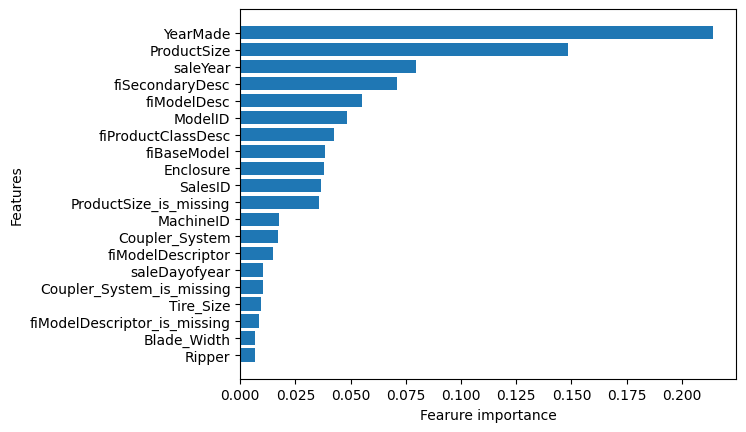

In [ ]:
plot_features(x_train.columns, ideal_model.feature_importances_)

In [ ]:
sum(ideal_model.feature_importances_)

np.float64(0.9999999999999997)

In [ ]:
df.ProductSize.isna().sum()

np.int64(183046)

In [ ]:
df.ProductSize.value_counts()

,count
ProductSize,
Medium,53993
Large / Medium,42132
Small,23810
Mini,20887
Large,18880
Compact,4770


In [ ]:
df.Turbocharged.value_counts()

,count
Turbocharged,
None or Unspecified,67453
Yes,3620


In [ ]:
df.Thumb.value_counts()

,count
Thumb,
None or Unspecified,72932
Manual,8132
Hydraulic,4218


### Extensions and Extra-curriculum

Extra-curriculum: read pandas io tools for info on parquet/feather data formats - IO tools documentation page.

See all of the pandas dtypes in the pandas user guide: https://pandas.pydata.org/docs/user_guide/basics.html#dtypes

Note: There are some ML models such as sklearn.ensemble.HistGradientBoostingRegressor, CatBoost and XGBoost which can handle missing values, however, I'll leave exploring each of these as extra-curriculum/extensions.